# Step G — Hydrogen gas network

**Task (Assignment 2, part g):** Assume that the countries of the Step D interconnected
system are also connected via gas pipelines transporting H₂ (or CH₄). Use a linear
approach to represent gas transport in pipelines. Optimise the network again and discuss
the results, including which of the two energy transport networks — electricity or H₂ —
is transporting more energy.

### Model

We extend the Step D interconnected system with a **parallel hydrogen network**:
- One H₂ bus per country (Denmark H2, Germany H2, Sweden H2, Norway H2)
- **Electrolysers** (extendable): electricity bus → H₂ bus, η = 70 % (alkaline)
- **Fuel cells** (extendable): H₂ bus → electricity bus, η = 58 %
- **H₂ pipelines** (fixed capacity): modelled as two directional `Link` per connection,
  each with efficiency 97 % (compression losses). Five connections are added, matching
  the electricity topology.

### Sources

- Electrolyser / fuel cell costs: DEA Technology Data, Renewable Fuels
- H₂ pipeline DK–DE capacity: European Hydrogen Backbone / Energinet (DHB1)
- Other pipeline capacities: assumed (no planned infrastructure)

**Requires in the working directory:** the same files as Step D
(`DK_2015_merged.csv`, `STEP D - electricity_demand.csv`, `Other country data/…`,
`functions_to_investigate.py`). The first code block rebuilds the Step D network
silently so that `net` is available for `net_g = net.copy()`.


## Imports

In [2]:
from pathlib import Path
import pypsa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import importlib
import functions_to_investigate as fti


## Rebuild the Step D network (silent)

This block reproduces the Step D setup exactly, then optimises. After this, `net` is the
post-optimisation Step D network, ready to be copied and extended with an H₂ network.


In [3]:
# ----- Cost table (same as Step A) -----
data = {
    "capital_cost": [
        1500000/25 + 60000,
        800000/25 + 14000,
        700000/25 + 24000,
    ],
    "marginal_cost": [0.0, 0.0, 9.5 * 3.6 / 0.56 + 2.30]
}
costs = pd.DataFrame(data, index=["wind_combined", "solar", "CCGT"])

# ----- Resolve paths -----
PROJECT_DIR = Path.cwd()
if not (PROJECT_DIR / "STEP D - electricity_demand.csv").exists():
    PROJECT_DIR = PROJECT_DIR.parent
cf_base = PROJECT_DIR / "Other country data" / "Energy charts data"

# ----- Denmark CFs + snapshot reference -----
dataframe_dk = pd.read_csv(PROJECT_DIR / "DK_2015_merged.csv", index_col=0, sep=",", parse_dates=True)
dataframe_dk.index = pd.to_datetime(dataframe_dk.index, utc=True).tz_localize(None)
dataframe_dk = dataframe_dk.sort_index()
CF_wind  = dataframe_dk["wind_cf_Unnamed: 1"].astype(float)
CF_solar = dataframe_dk["pv_cf_Unnamed: 1"].astype(float)
snapshots = dataframe_dk.index

# ----- Multi-country demand -----
demand_all = pd.read_csv(PROJECT_DIR / "STEP D - electricity_demand.csv",
                         sep=";", index_col=0, parse_dates=True)
demand_all.index = pd.to_datetime(demand_all.index, utc=True).tz_localize(None)
demand_all = demand_all.sort_index()
demand_2015 = demand_all[demand_all.index.year == 2015].copy()
demand_dk = demand_2015["DNK"].astype(float).reindex(snapshots)
demand_de = demand_2015["DEU"].astype(float).reindex(snapshots)
demand_se = demand_2015["SWE"].astype(float).reindex(snapshots)
demand_no = demand_2015["NOR"].astype(float).reindex(snapshots)

# ----- Neighbour CFs -----
cf_de_raw = pd.read_csv(cf_base / "Germany" / "Germany_hourly_capacity_factors.csv")
cf_de_raw["timestamp"] = pd.to_datetime(cf_de_raw["timestamp"])
cf_de_raw = cf_de_raw.set_index("timestamp").sort_index()
cf_de_raw.index = cf_de_raw.index.tz_localize(None)
cf_de = cf_de_raw.resample("h").mean()
cf_de["wind_combined"] = cf_de["Wind onshore"]
cf_de["solar"] = cf_de["Solar AC"]
cf_de["CCGT"]  = cf_de["Fossil gas"]
cf_de["nuclear"] = cf_de["Nuclear"]
cf_de = cf_de[["wind_combined", "solar", "CCGT", "nuclear"]].reindex(snapshots)

cf_se = pd.read_csv(cf_base / "Sweden" / "Sweden_hourly_capacity_factors.csv")
cf_se["timestamp"] = pd.to_datetime(cf_se["timestamp"])
cf_se = cf_se.set_index("timestamp").sort_index()
cf_se.index = cf_se.index.tz_localize(None)
cf_se["wind_combined"] = cf_se["Wind onshore"]
cf_se["nuclear"] = cf_se["Nuclear"]
cf_se["hydro"]   = cf_se["Hydro water reservoir"]
cf_se = cf_se[["wind_combined", "nuclear", "hydro"]].reindex(snapshots).bfill()

cf_no = pd.read_csv(cf_base / "Norway" / "Norway_hourly_capacity_factors.csv")
cf_no["timestamp"] = pd.to_datetime(cf_no["timestamp"])
cf_no = cf_no.set_index("timestamp").sort_index()
cf_no.index = cf_no.index.tz_localize(None)
cf_no["wind_combined"] = cf_no["Wind onshore"]
cf_no["hydro"] = cf_no["Hydro water reservoir"]
cf_no = cf_no[["wind_combined", "hydro"]].reindex(snapshots)

# ----- Build the network -----
net = pypsa.Network()
net.set_snapshots(snapshots)
for name, (x, y) in {"Denmark": (10.0, 56.0), "Germany": (10.5, 51.5),
                     "Sweden": (15.0, 59.5), "Norway": (10.0, 62.0)}.items():
    net.add("Bus", name, x=x, y=y)

net.add("Load", "load_DK", bus="Denmark", p_set=demand_dk.values)
net.add("Load", "load_DE", bus="Germany", p_set=demand_de.values)
net.add("Load", "load_SE", bus="Sweden",  p_set=demand_se.values)
net.add("Load", "load_NO", bus="Norway",  p_set=demand_no.values)

net.add("Carrier", ["wind_onshore", "solar", "CCGT",
                    "hydro", "nuclear", "coal", "battery"],
        color=["blue", "yellow", "brown", "cyan", "purple", "grey", "purple"])

# Denmark — extendable
net.add("Generator", "DK_wind", bus="Denmark", carrier="wind_combined",
        capital_cost=costs.loc["wind_combined", "capital_cost"],
        marginal_cost=costs.loc["wind_combined", "marginal_cost"],
        p_max_pu=CF_wind.values, p_nom_extendable=True)
net.add("Generator", "DK_solar", bus="Denmark", carrier="solar",
        capital_cost=costs.loc["solar", "capital_cost"],
        marginal_cost=costs.loc["solar", "marginal_cost"],
        p_max_pu=CF_solar.values, p_nom_extendable=True)
net.add("Generator", "DK_CCGT", bus="Denmark", carrier="CCGT",
        capital_cost=costs.loc["CCGT", "capital_cost"],
        marginal_cost=costs.loc["CCGT", "marginal_cost"],
        efficiency=0.58, p_nom_extendable=True)

# Germany — fixed
net.add("Generator", "DE_wind", bus="Germany", carrier="wind_combined",
        p_nom=41300, marginal_cost=0, p_max_pu=cf_de["wind_combined"].values,
        p_nom_extendable=False)
net.add("Generator", "DE_solar", bus="Germany", carrier="solar",
        p_nom=37000, marginal_cost=0, p_max_pu=cf_de["solar"].values,
        p_nom_extendable=False)
net.add("Generator", "DE_CCGT", bus="Germany", carrier="CCGT",
        p_nom=28360, marginal_cost=60.0, p_nom_extendable=False)
net.add("Generator", "DE_nuclear", bus="Germany", carrier="nuclear",
        p_nom=10800, marginal_cost=10.0, p_nom_extendable=False)
net.add("Generator", "DE_coal", bus="Germany", carrier="coal",
        p_nom=21420, marginal_cost=30.0, p_nom_extendable=False)

# Sweden — fixed
net.add("Generator", "SE_hydro", bus="Sweden", carrier="hydro",
        p_nom=15920, marginal_cost=5.0, p_max_pu=cf_se["hydro"].values,
        p_nom_extendable=False)
net.add("Generator", "SE_nuclear", bus="Sweden", carrier="nuclear",
        p_nom=8900, marginal_cost=10.0, p_nom_extendable=False)
net.add("Generator", "SE_wind", bus="Sweden", carrier="wind_combined",
        p_nom=5500, marginal_cost=0, p_max_pu=cf_se["wind_combined"].values,
        p_nom_extendable=False)

# Norway — fixed
net.add("Generator", "NO_hydro", bus="Norway", carrier="hydro",
        p_nom=29900, marginal_cost=5.0, p_max_pu=cf_no["hydro"].values,
        p_nom_extendable=False)
net.add("Generator", "NO_wind", bus="Norway", carrier="wind_combined",
        p_nom=700, marginal_cost=0, p_max_pu=cf_no["wind_combined"].values,
        p_nom_extendable=False)

# Transmission lines
for bus in net.buses.index:
    net.buses.loc[bus, "v_nom"] = 380
for name, bus0, bus1, s_nom, length in [
    ("line_DK_DE", "Denmark", "Germany", 3500, 360),
    ("line_DK_SE", "Denmark", "Sweden",  1700, 520),
    ("line_DK_NO", "Denmark", "Norway",  1050, 570),
    ("line_SE_NO", "Sweden",  "Norway",  3500, 480),
    ("line_DE_SE", "Germany", "Sweden",   600, 820),
]:
    net.add("Line", name, bus0=bus0, bus1=bus1,
            s_nom=s_nom, x=0.1, r=0.01, length=length, p_nom=s_nom)

# Batteries (2024 Li-ion costs)
b_cap = 100_000 / 20 + 12_500 + (150_000 / 20) * 4   # 47,500 $/MW/year
for country, bus in [("DK", "Denmark"), ("DE", "Germany"),
                     ("SE", "Sweden"),  ("NO", "Norway")]:
    net.add("StorageUnit", f"{country}_battery", bus=bus, carrier="battery",
            capital_cost=b_cap, marginal_cost=0,
            efficiency_store=0.90**0.5, efficiency_dispatch=0.90**0.5,
            max_hours=4, cyclic_state_of_charge=True, p_nom_extendable=True)

# Optimise the Step D system
net.optimize(solver_name="gurobi", solver_options={"output_flag": False})
print(f"Step D rebuilt — system cost: {net.objective/1e9:.3f} B$/y")


C:\Users\terry\AppData\Local\Temp\ipykernel_34036\3084799030.py:151: FutureWarning:

The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.

Index(['Denmark', 'Germany', 'Sweden', 'Norway'], dtype='str', name='name')
Index(['DK_wind', 'DE_wind', 'SE_wind', 'NO_wind'], dtype='str', name='name')
DatetimeIndex(['2015-12-31 23:00:00'], dtype='datetime64[us]', name='snapshot', freq=None)
DatetimeIndex(['2015-12-31 23:00:00'], dtype='datetime64[us]', name='snapshot', freq=None)
DatetimeIndex(['2015-12-31 23:00:00'], dtype='datetime64[us]', name='snapshot', freq=None)
DatetimeIndex(['2015-12-31 23:00:00'], dtype='datetime64[us]', name='snapshot', freq=None)
DatetimeIndex(['2015-10-25 01:00:00', '2015-12-31 23:00:00'], dtype='datetime64[us]', name='snapshot', freq=None)
DatetimeIndex

Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2773895


INFO:gurobipy:Set parameter LicenseID to value 2773895


...

Reading time = 0.92 seconds


INFO:gurobipy:Reading time = 0.92 seconds


obj: 613207 rows, 262807 columns, 1116871 nonzeros


INFO:gurobipy:obj: 613207 rows, 262807 columns, 1116871 nonzeros
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 262807 primals, 613207 duals
Objective: 2.14e+10
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Line-fix-s-lower, Line-fix-s-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, Kirchhoff-Voltage-Law, StorageUnit-energy_balance were not assigned to the network.


Step D rebuilt — system cost: 21.382 B$/y


## H₂ technology assumptions

In [4]:
# H2 technology assumptions

# Electrolyser (alkaline, 2025 estimates)
electrolyser_investment = 600000   # $/MW
electrolyser_lifetime   = 25       # years
electrolyser_fom        = 12000    # $/MW/year (2% of investment)
electrolyser_capex      = electrolyser_investment / electrolyser_lifetime + electrolyser_fom  # 36,000 $/MW/y
electrolyser_efficiency = 0.70     # electricity → H2 (LHV)

# Fuel cell / H2 turbine (reconversion H2 → electricity)
fuelcell_investment = 700000       # $/MW
fuelcell_lifetime   = 25           # years
fuelcell_fom        = 24000        # $/MW/year
fuelcell_capex      = fuelcell_investment / fuelcell_lifetime + fuelcell_fom  # 52,000 $/MW/y
fuelcell_efficiency = 0.58         # H2 → electricity

# H2 pipeline efficiency (compression losses)
pipeline_efficiency = 0.97

# H2 pipeline capacities [MW]
h2_pipeline_cap = {
    "H2_DK_DE": 3600,   # EHB / Energinet (DHB1)
    "H2_DK_SE": 1750,   # assumed
    "H2_DK_NO": 1100,   # assumed
    "H2_SE_NO": 3600,   # assumed
    "H2_DE_SE": 650,   # assumed
}

print("--- Step G: H2 technology assumptions ---")
print(f"Electrolyser:  {electrolyser_capex/1e3:.0f} k$/MW/y, η = {electrolyser_efficiency:.0%}")
print(f"Fuel cell:     {fuelcell_capex/1e3:.0f} k$/MW/y, η = {fuelcell_efficiency:.0%}")
print(f"Pipeline η:    {pipeline_efficiency:.0%}")


--- Step G: H2 technology assumptions ---
Electrolyser:  36 k$/MW/y, η = 70%
Fuel cell:     52 k$/MW/y, η = 58%
Pipeline η:    97%


## Copy the Step D network and add the H₂ layer

In [5]:
# Copy the Step D network and add H2 carrier + buses

net.model.solver_model = None
net_g = net.copy()

net_g.add("Carrier", "H2", color="#2ecc71")

countries = ["Denmark", "Germany", "Sweden", "Norway"]
for c in countries:
    net_g.add("Bus", f"{c} H2", carrier="H2")

print(f"Buses: {list(net_g.buses.index)}")


Buses: ['Denmark', 'Germany', 'Sweden', 'Norway', 'Denmark H2', 'Germany H2', 'Sweden H2', 'Norway H2']


In [6]:
# Add electrolysers: electricity bus → H2 bus (extendable)

for c in countries:
    net_g.add("Link", f"{c} electrolyser",
              bus0=c,
              bus1=f"{c} H2",
              carrier="H2",
              capital_cost=electrolyser_capex,
              efficiency=electrolyser_efficiency,
              p_nom_extendable=True)

print("Electrolysers added:", [f"{c} electrolyser" for c in countries])


Electrolysers added: ['Denmark electrolyser', 'Germany electrolyser', 'Sweden electrolyser', 'Norway electrolyser']


In [7]:
# Add fuel cells: H2 bus → electricity bus (extendable)

for c in countries:
    net_g.add("Link", f"{c} fuel cell",
              bus0=f"{c} H2",
              bus1=c,
              carrier="H2",
              capital_cost=fuelcell_capex,
              efficiency=fuelcell_efficiency,
              p_nom_extendable=True)

print("Fuel cells added:", [f"{c} fuel cell" for c in countries])


Fuel cells added: ['Denmark fuel cell', 'Germany fuel cell', 'Sweden fuel cell', 'Norway fuel cell']


In [8]:
# Add H2 pipelines (fixed capacity, two links per connection for each direction)

h2_connections = [
    ("DK", "DE", "Denmark H2", "Germany H2", 3600),   # EHB / Energinet
    ("DK", "SE", "Denmark H2", "Sweden H2",  1500),   # assumed
    ("DK", "NO", "Denmark H2", "Norway H2",  2000),   # assumed
    ("SE", "NO", "Sweden H2",  "Norway H2",  2000),   # assumed
    ("DE", "SE", "Germany H2", "Sweden H2",  1000),   # assumed
]

for c0, c1, bus0, bus1, cap in h2_connections:
    # Forward: bus0 → bus1
    net_g.add("Link", f"H2_{c0}_{c1}",
              bus0=bus0, bus1=bus1,
              carrier="H2",
              p_nom=cap,
              efficiency=pipeline_efficiency,
              p_nom_extendable=False)
    # Backward: bus1 → bus0
    net_g.add("Link", f"H2_{c1}_{c0}",
              bus0=bus1, bus1=bus0,
              carrier="H2",
              p_nom=cap,
              efficiency=pipeline_efficiency,
              p_nom_extendable=False)

print("H2 pipelines added (2 links per connection):")
for c0, c1, _, _, cap in h2_connections:
    print(f"  {c0} ↔ {c1}: {cap} MW (each direction)")


H2 pipelines added (2 links per connection):
  DK ↔ DE: 3600 MW (each direction)
  DK ↔ SE: 1500 MW (each direction)
  DK ↔ NO: 2000 MW (each direction)
  SE ↔ NO: 2000 MW (each direction)
  DE ↔ SE: 1000 MW (each direction)


## Optimise the combined electricity + H₂ network

In [9]:
# Optimize the combined electricity + H2 network

net_g.optimize(solver_name="gurobi", 
               solver_options={"output_flag": False},
               progress=False)

print(f"System cost Step D: {net.objective/1e9:.3f} B$/y")
print(f"System cost Step G: {net_g.objective/1e9:.3f} B$/y")
print(f"Difference:         {(net_g.objective - net.objective)/1e9:+.3f} B$/y")


# Results: electrolyser and fuel cell capacities

print("--- Electrolyser capacities [MW] ---")
for c in countries:
    cap = net_g.links.loc[f"{c} electrolyser", "p_nom_opt"]
    print(f"  {c}: {cap:.1f} MW")

print("\n--- Fuel cell capacities [MW] ---")
for c in countries:
    cap = net_g.links.loc[f"{c} fuel cell", "p_nom_opt"]
    print(f"  {c}: {cap:.1f} MW")


C:\Users\terry\AppData\Local\Temp\ipykernel_34036\2677287530.py:3: FutureWarning:

The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.

Index(['Denmark', 'Germany', 'Sweden', 'Norway'], dtype='str', name='name')
Index(['DK_wind', 'DE_wind', 'SE_wind', 'NO_wind'], dtype='str', name='name')
DatetimeIndex(['2015-12-31 23:00:00'], dtype='datetime64[us]', name='snapshot', freq=None)
DatetimeIndex(['2015-12-31 23:00:00'], dtype='datetime64[us]', name='snapshot', freq=None)
DatetimeIndex(['2015-12-31 23:00:00'], dtype='datetime64[us]', name='snapshot', freq=None)
DatetimeIndex(['2015-12-31 23:00:00'], dtype='datetime64[us]', name='snapshot', freq=None)
DatetimeIndex(['2015-10-25 01:00:00', '2015-12-31 23:00:00'], dtype='datetime64[us]', name='snapshot', freq=None)
DatetimeIndex([

Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2773895


INFO:gurobipy:Set parameter LicenseID to value 2773895


...

Reading time = 1.28 seconds


INFO:gurobipy:Reading time = 1.28 seconds


obj: 963615 rows, 420495 columns, 1817679 nonzeros


INFO:gurobipy:obj: 963615 rows, 420495 columns, 1817679 nonzeros
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 420495 primals, 963615 duals
Objective: 1.84e+10
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Line-fix-s-lower, Line-fix-s-upper, Link-fix-p-lower, Link-fix-p-upper, Link-ext-p-lower, Link-ext-p-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, Kirchhoff-Voltage-Law, StorageUnit-energy_balance were not assigned to the network.


System cost Step D: 21.382 B$/y
System cost Step G: 18.395 B$/y
Difference:         -2.986 B$/y
--- Electrolyser capacities [MW] ---
  Denmark: 261.7 MW
  Germany: 0.0 MW
  Sweden: 3157.6 MW
  Norway: 3379.3 MW

--- Fuel cell capacities [MW] ---
  Denmark: 0.0 MW
  Germany: 4440.9 MW
  Sweden: 0.0 MW
  Norway: 0.0 MW


## Which network transports more energy?

In [10]:
# Results: compare electricity vs H2 total annual energy transport

# Electricity: sum of |flow| on all HVAC lines
el_transport_twh = net_g.lines_t.p0.abs().sum().sum() / 1e6

# H2 pipelines: filter links that start with "H2_"
h2_pipe_names = [n for n in net_g.links.index if n.startswith("H2_")]
h2_transport_twh = net_g.links_t.p0[h2_pipe_names].abs().sum().sum() / 1e6

print("--- Energy transport comparison ---")
print(f"Electricity network: {el_transport_twh:.2f} TWh/y")
print(f"H2 pipeline network: {h2_transport_twh:.2f} TWh/y")
print(f"Ratio H2/Electricity: {h2_transport_twh/el_transport_twh:.2%}")

if h2_transport_twh > el_transport_twh:
    print("→ The H2 network transports MORE energy than the electricity network.")
else:
    print("→ The electricity network transports MORE energy than the H2 network.")


--- Energy transport comparison ---
Electricity network: 30.87 TWh/y
H2 pipeline network: 42.43 TWh/y
Ratio H2/Electricity: 137.46%
→ The H2 network transports MORE energy than the electricity network.


## Impact on Denmark: capacity comparison Step D vs Step G

In [11]:
# Results: Denmark capacity comparison Step D vs Step G

print("--- Denmark optimal capacities: Step D vs Step G ---")
dk_gens_d = net.generators[net.generators.bus == "Denmark"]
dk_gens_g = net_g.generators[net_g.generators.bus == "Denmark"]

for gen_d, gen_g in zip(dk_gens_d.index, dk_gens_g.index):
    cap_d = dk_gens_d.loc[gen_d, "p_nom_opt"] / 1e3
    cap_g = dk_gens_g.loc[gen_g, "p_nom_opt"] / 1e3
    carrier = dk_gens_d.loc[gen_d, "carrier"]
    print(f"  {carrier:15s}: {cap_d:.2f} → {cap_g:.2f} GW")


--- Denmark optimal capacities: Step D vs Step G ---
  wind_combined  : 5.94 → 6.68 GW
  solar          : 0.00 → 0.00 GW
  CCGT           : 7.89 → 7.20 GW


## Plots

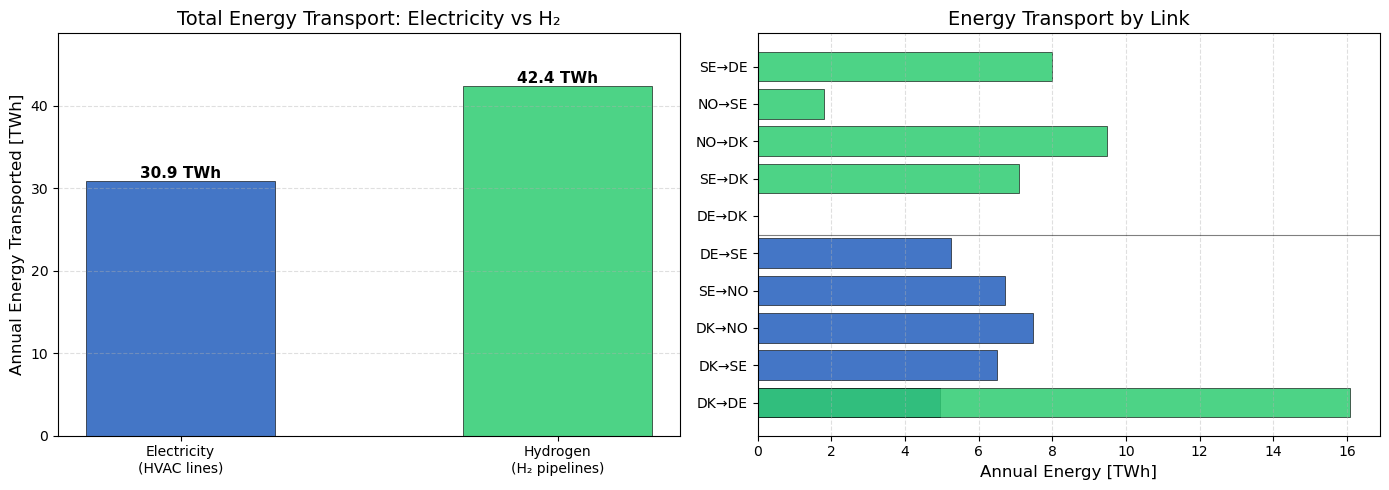

In [12]:
importlib.reload(fti)
fti.plot_energy_transport_comparison(net_g)


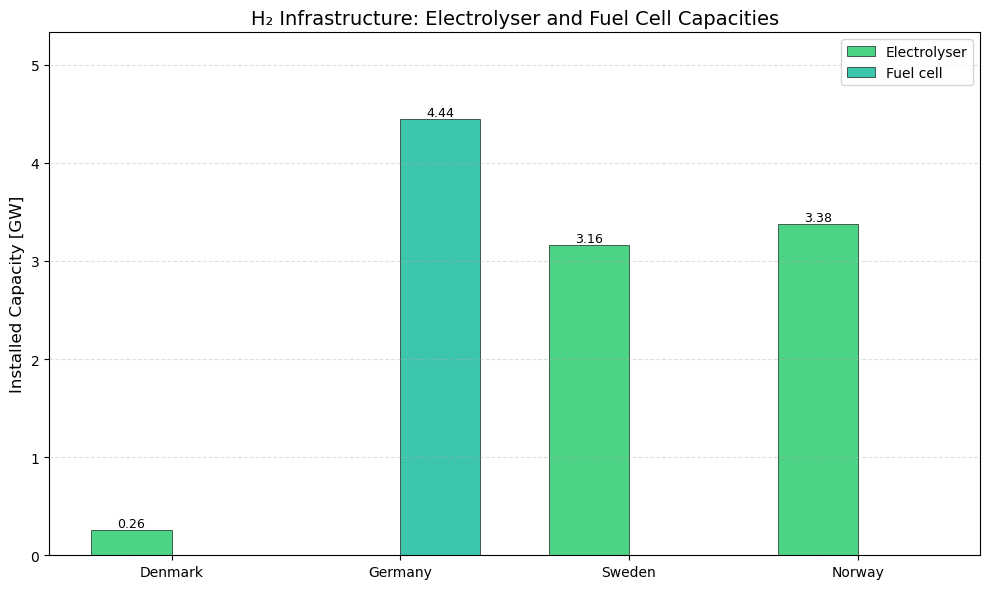

In [13]:
fti.plot_h2_infrastructure(net_g)


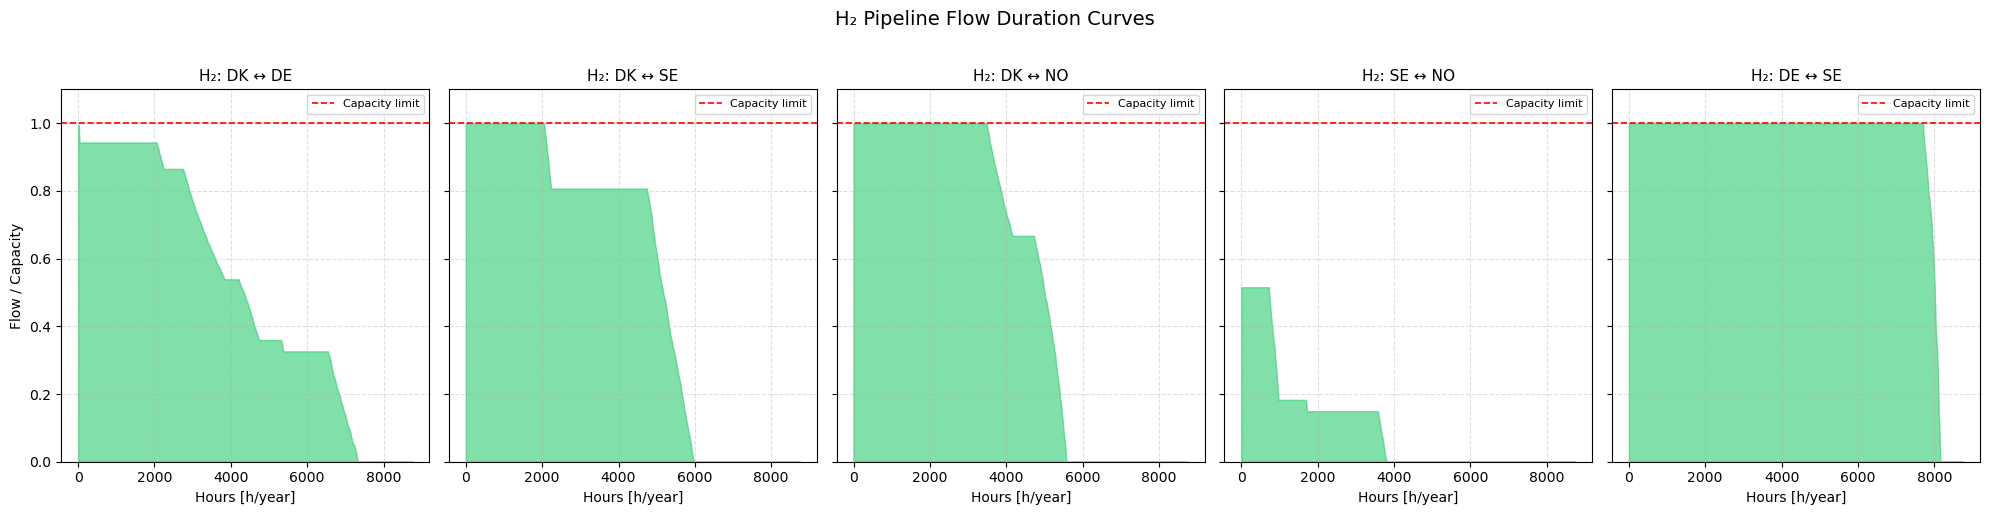

In [14]:
fti.plot_h2_pipeline_utilization(net_g)


STEP I

In [15]:
import pandas as pd

# Data sourced from Heat Roadmap Europe (HRE4) screenshots and population-scaled estimates (NO)
# Units are in TWh/year for the year 2015
heat_data = {
    "Country": ["Germany", "Sweden", "Denmark", "Norway"],
    "Space Heating [TWh]": [675.0, 33.6, 33.6, 17.8],  # Values from HRE4 screenshots
    "Hot Water [TWh]": [143.0, 7.7, 7.7, 4.1],        # Values from HRE4 screenshots
    "Total Heat [TWh]": [818.0, 41.3, 41.3, 21.9],     # Total annual thermal demand
    "Calculation Method": [
        "HRE4 Primary Data", 
        "HRE4 Primary Data", 
        "HRE4 Primary Data", 
        "Scaled from SE (53% population ratio)"
    ]
}

# Create DataFrame
df_heat_summary = pd.DataFrame(heat_data)

# Calculate percentage split for Space Heating (useful for the report discussion)
df_heat_summary["Space Heating %"] = (
    (df_heat_summary["Space Heating [TWh]"] / df_heat_summary["Total Heat [TWh]"]) * 100
).round(1)

# Display the formatted table
print("Table: Annual Residential Heat Demand for Sector Coupling (2015)")
print("=" * 85)
print(df_heat_summary.to_string(index=False))
print("=" * 85)

# Quick conversion helper for PyPSA (TWh to MWh)
# total_mwh = df_heat_summary.loc[df_heat_summary['Country'] == 'Denmark', 'Total Heat [TWh]'].values[0] * 1e6

Table: Annual Residential Heat Demand for Sector Coupling (2015)
Country  Space Heating [TWh]  Hot Water [TWh]  Total Heat [TWh]                    Calculation Method  Space Heating %
Germany                675.0            143.0             818.0                     HRE4 Primary Data             82.5
 Sweden                 33.6              7.7              41.3                     HRE4 Primary Data             81.4
Denmark                 33.6              7.7              41.3                     HRE4 Primary Data             81.4
 Norway                 17.8              4.1              21.9 Scaled from SE (53% population ratio)             81.3


In [16]:
import pandas as pd
import numpy as np
import os

# --- SETTINGS ---
T_threshold = 17.0
countries = {
    "DE": "Germany",
    "DK": "Denmark",
    "SE": "Sweden",
    "NO": "Norway"
}

# Name of the compact output file
PROCESSED_TEMP_FILE = "weather_data_2015_filtered.csv"

In [17]:
# Load the pre-filtered 2015 temperature data
weather_2015 = pd.read_csv(PROCESSED_TEMP_FILE, index_col=0, parse_dates=True)

# Calculate Heating Degree Hours (HDH) based on the threshold
# HDH = max(0, T_threshold - T_ambient)
hdh_data = (T_threshold - weather_2015).clip(lower=0)

# Rename columns to reflect HDH
hdh_data.columns = [c.replace("Temp_", "HDH_") for c in hdh_data.columns]

print("2015 Weather Data and HDH calculation ready:")
display(hdh_data.head())

2015 Weather Data and HDH calculation ready:


,HDH_DE,HDH_DK,HDH_SE,HDH_NO
time,,,,
2015-01-01 00:00:00+00:00,18.106,13.039,16.301,16.118
2015-01-01 01:00:00+00:00,18.161,12.751,16.204,16.174
2015-01-01 02:00:00+00:00,18.234,12.460,16.037,16.051
2015-01-01 03:00:00+00:00,18.287,12.341,15.804,15.881
2015-01-01 04:00:00+00:00,18.340,12.374,15.557,15.817


In [18]:
# --- 1. DEFINE ANNUAL DEMANDS (TWh to MWh) ---
# Values converted from TWh to MWh (1 TWh = 1,000,000 MWh)
annual_demand_mwh = {
    "DE": {"space": 675.0 * 1e6, "water": 143.0 * 1e6},
    "DK": {"space": 33.6 * 1e6,  "water": 7.7 * 1e6},
    "SE": {"space": 33.6 * 1e6,  "water": 7.7 * 1e6},
    "NO": {"space": 17.8 * 1e6,  "water": 4.1 * 1e6}
}

final_heat_profiles_mw = pd.DataFrame(index=hdh_data.index)

print("Calculating hourly heat profiles (MW)...")

# --- 2. CALCULATE SCALING AND HOURLY PROFILES ---
for code in countries.keys():
    # Use the HDH column from the pre-processed hdh_data DataFrame
    hdh_series = hdh_data[f"HDH_{code}"]
    
    # Sum of all HDH in the year 2015
    total_hdh_sum = hdh_series.sum()
    
    # Calculate f1 (Scaling factor for space heating in MW/K)
    f1 = annual_demand_mwh[code]["space"] / total_hdh_sum
    
    # Calculate constant baseload for water heating (MW)
    # 8760 hours in 2015
    water_baseload = annual_demand_mwh[code]["water"] / 8760
    
    # Generate final hourly profile: (f1 * HDH) + baseload
    final_heat_profiles_mw[code] = (f1 * hdh_series) + water_baseload
    
    print(f"Country: {code}")
    print(f" > f1 Scaling Factor: {f1:.2f} MW/K")
    print(f" > Water Baseload: {water_baseload:.2f} MW")
    print(f" > Peak Heat Load: {final_heat_profiles_mw[code].max():.2f} MW\n")

# --- 3. ASSIGN TO PYPSA NETWORK ---
# Example of how to map these profiles to your existing load components
for code, name in countries.items():
    load_name = f"{code} heat load"
    if load_name in net_g.loads.index:
        net_g.loads_t.p_set[load_name] = final_heat_profiles_mw[code].values
        print(f"Assigned {load_name} to the network.")

print("\nAll heat profiles successfully updated.")

Calculating hourly heat profiles (MW)...
Country: DE
 > f1 Scaling Factor: 9540.59 MW/K
 > Water Baseload: 16324.20 MW
 > Peak Heat Load: 257596.16 MW

Country: DK
 > f1 Scaling Factor: 474.18 MW/K
 > Water Baseload: 879.00 MW
 > Peak Heat Load: 10774.17 MW

Country: SE
 > f1 Scaling Factor: 386.79 MW/K
 > Water Baseload: 879.00 MW
 > Peak Heat Load: 10664.44 MW

Country: NO
 > f1 Scaling Factor: 174.50 MW/K
 > Water Baseload: 468.04 MW
 > Peak Heat Load: 5428.49 MW


All heat profiles successfully updated.


In [20]:
# --- 1. SETTINGS ---
T_sink = 55.0  # Fixed sink temperature (e.g., for district heating or radiators)
cop_profiles = pd.DataFrame(index=weather_2015.index)

print("Calculating hourly COP profiles for Heat Pumps...")

# --- 2. CALCULATION LOOP ---
for code in countries.keys():
    # Use the temperature data from our pre-processed DataFrame
    t_source = weather_2015[f"Temp_{code}"]
    
    # Calculate temperature lift (Delta T)
    delta_t = T_sink - t_source
    
    # Quadratic regression formula for COP modeling
    # COP = 6.81 - 0.121 * ΔT + 0.00063 * ΔT²
    cop = 6.81 - 0.121 * delta_t + 0.00063 * (delta_t**2)
    
    # Safety clip: COP cannot drop below 1.0 (electric resistance limit)
    cop = cop.clip(lower=1.0)
    
    # Store in our consolidated DataFrame
    cop_profiles[code] = cop
    
    print(f"Country: {code}")
    print(f" > Mean COP: {cop.mean():.2f}")
    print(f" > Min COP (Coldest): {cop.min():.2f}")
    print(f" > Max COP (Warmest): {cop.max():.2f}\n")

# --- 3. PYPSA INTEGRATION ---
# Update the efficiency of the heat pump links in the network
for code, name in countries.items():
    hp_name = f"{code} heat pump"
    if hp_name in net_g.links.index:
        # PyPSA efficiency for a heat pump is the COP time series
        net_g.links_t.efficiency[hp_name] = cop_profiles[code].values
        print(f"Updated COP for {hp_name}")

print("\nAll COP profiles successfully integrated into the network.")

Calculating hourly COP profiles for Heat Pumps...
Country: DE
 > Mean COP: 2.66
 > Min COP (Coldest): 1.68
 > Max COP (Warmest): 4.57

Country: DK
 > Mean COP: 2.60
 > Min COP (Coldest): 1.87
 > Max COP (Warmest): 3.81

Country: SE
 > Mean COP: 2.49
 > Min COP (Coldest): 1.68
 > Max COP (Warmest): 3.70

Country: NO
 > Mean COP: 2.38
 > Min COP (Coldest): 1.55
 > Max COP (Warmest): 3.45


All COP profiles successfully integrated into the network.


In [23]:
# --- 1. HEAT PUMP CAPEX CALCULATION (DEA Catalogue) ---
# Data for large-scale air-source heat pumps
hp_capex_per_mwe = 730000  # EUR/MW_e (Cost based on electrical input)
hp_fixed_om = 12500        # EUR/MW_e/year
hp_lifetime = 25           # Years
wacc = 0.07                # Discount rate (7%)

# Calculate Annuity (Capital Recovery Factor)
annuity = (wacc * (1 + wacc)**hp_lifetime) / ((1 + wacc)**hp_lifetime - 1)

# Total annualized capital cost for PyPSA (approx 75,000 EUR/MW/year)
hp_capital_cost = (hp_capex_per_mwe * annuity) + hp_fixed_om
print(f"Calculated Heat Pump Capital Cost: {hp_capital_cost:.2f} EUR/MW/year")

Calculated Heat Pump Capital Cost: 75141.68 EUR/MW/year


In [30]:
# --- 1. SETTINGS & HEAT LOGIC ---
countries_map = {"DE": "Germany", "DK": "Denmark", "SE": "Sweden", "NO": "Norway"}

# Heat Pump Capex Calculation (from DEA Catalogue: 0.73 MEUR/MW_e)
hp_investment = 730000 
hp_lifetime = 25
wacc = 0.07 
annuity = (wacc * (1 + wacc)**hp_lifetime) / ((1 + wacc)**hp_lifetime - 1)
hp_capital_cost = (hp_investment * annuity) + 12500 # Including Fixed O&M

# Efficiency logic: 1 - elec_eff - 5% (losses)
ccgt_eff_elec = 0.58
ccgt_eff_heat = 1 - ccgt_eff_elec - 0.05 # 0.37

# For Fuel Cells, we use the efficiency defined in your Step G/costs
fc_eff_elec = 0.58 
fc_eff_heat = 1 - fc_eff_elec - 0.05 # 0.37

print(f"CCGT CHP Logic: {ccgt_eff_elec*100}% Elec, {ccgt_eff_heat*100}% Heat Recovery")
print(f"Fuel Cell CHP Logic: {fc_eff_elec*100}% Elec, {fc_eff_heat*100}% Heat Recovery")

CCGT CHP Logic: 57.99999999999999% Elec, 37.00000000000001% Heat Recovery
Fuel Cell CHP Logic: 57.99999999999999% Elec, 37.00000000000001% Heat Recovery


In [31]:
# --- 2. INTEGRATION OF CHP AND HEAT PUMPS ---

# Remove old CCGT generators to replace them with dual-output Links
old_ccgt = net.generators[net.generators.carrier == "CCGT"].index.tolist()
for gen in old_ccgt:
    net.remove("Generator", gen)

for code, country in countries_map.items():
    # A. Add Heat Bus and Heat Load if not present
    if f"{country} heat" not in net.buses.index:
        net.add("Bus", f"{country} heat", carrier="heat", location=country)
        net.add("Load", f"{country} heat load",
                bus=f"{country} heat",
                p_set=final_heat_profiles_mw[code].values)

    # B. Add Heat Pumps (Link: Elec -> Heat)
    net.add("Link", f"{country} heat pump",
            bus0=country,
            bus1=f"{country} heat",
            carrier="heat pump",
            efficiency=cop_profiles[code].values,
            capital_cost=hp_capital_cost,
            p_nom_extendable=True)

    # C. Add CCGT CHP (Link: Gas -> Elec + Heat)
    # Using costs directly from your 'costs' dataframe
    net.add("Link", f"{country} CCGT CHP",
            bus0=f"{country} gas" if f"{country} gas" in net.buses.index else country,
            bus1=country,
            bus2=f"{country} heat",
            carrier="CCGT",
            efficiency=ccgt_eff_elec,
            efficiency2=ccgt_eff_heat,
            capital_cost=costs.at["CCGT", "capital_cost"],
            marginal_cost=costs.at["CCGT", "marginal_cost"],
            p_nom_extendable=True)

    # D. Retrofit existing Fuel Cells for Waste Heat Recovery
    fc_name = f"{country} Fuel Cell"
    if fc_name in net.links.index:
        net.links.at[fc_name, "bus2"] = f"{country} heat"
        net.links.at[fc_name, "efficiency2"] = fc_eff_heat

print("Sector coupling components integrated successfully.")

Sector coupling components integrated successfully.


In [32]:
# --- 3. MASTER RESULTS TABLE ---
net.optimize(solver_name="gurobi")

results = []
for code, country in countries_map.items():
    # 1. Electricity Demand (TWh)
    elec_load_cols = [c for c in net.loads_t.p.columns if country in c and "heat" not in c.lower()]
    elec_demand = net.loads_t.p[elec_load_cols].sum().sum() / 1e6
    
    # 2. Capacities (GW)
    gens = net.generators[net.generators.bus == country]
    wind_cap = gens[gens.carrier == "wind"].p_nom_opt.sum() / 1e3
    solar_cap = gens[gens.carrier == "solar"].p_nom_opt.sum() / 1e3
    ccgt_cap = net.links.at[f"{country} CCGT CHP", "p_nom_opt"] / 1e3
    hp_cap_e = net.links.at[f"{country} heat pump", "p_nom_opt"] / 1e3
    
    # 3. Generation (TWh)
    wind_gen = net.generators_t.p[gens[gens.carrier == "wind"].index].sum().sum() / 1e6
    solar_gen = net.generators_t.p[gens[gens.carrier == "solar"].index].sum().sum() / 1e6
    ccgt_elec = abs(net.links_t.p1[f"{country} CCGT CHP"].sum()) / 1e6
    fc_name = f"{country} Fuel Cell"
    fc_elec = abs(net.links_t.p1[fc_name].sum()) / 1e6 if fc_name in net.links_t.p1.columns else 0
    
    # 4. Import / Export Balance (TWh)
    hp_cons = net.links_t.p0[f"{country} heat pump"].sum() / 1e6
    net_import = (elec_demand + hp_cons) - (wind_gen + solar_gen + ccgt_elec + fc_elec)
    
    # 5. Heat Balance (TWh)
    heat_demand = net.loads_t.p[f"{country} heat load"].sum() / 1e6
    hp_heat = abs(net.links_t.p1[f"{country} heat pump"].sum()) / 1e6
    ccgt_waste = abs(net.links_t.p2[f"{country} CCGT CHP"].sum()) / 1e6
    fc_waste = abs(net.links_t.p2[fc_name].sum()) / 1e6 if fc_name in net.links_t.p2.columns else 0
    
    results.append({
        "Country": code,
        "Wind Cap [GW]": wind_cap,
        "Solar Cap [GW]": solar_cap,
        "CCGT Cap [GW]": ccgt_cap,
        "HP Cap [GW_e]": hp_cap_e,
        "Wind Gen [TWh]": wind_gen,
        "CCGT Elec [TWh]": ccgt_elec,
        "FC Elec [TWh]": fc_elec,
        "Net Import [TWh]": net_import,
        "Heat Demand [TWh]": heat_demand,
        "Heat Pump [TWh]": hp_heat,
        "Waste Heat [TWh]": ccgt_waste + fc_waste
    })

df_master = pd.DataFrame(results).set_index("Country")
print("--- FINAL MASTER RESULTS TABLE ---")
display(df_master.round(2))

C:\Users\terry\AppData\Local\Temp\ipykernel_34036\3760954688.py:2: FutureWarning:

The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.

Index(['Denmark', 'Germany', 'Sweden', 'Norway', 'Germany heat',
       'Denmark heat', 'Sweden heat', 'Norway heat', 'Germany gas',
       'Denmark gas', 'Sweden gas', 'Norway gas'],
      dtype='str', name='name')
Index(['DK_wind', 'DE_wind', 'SE_wind', 'NO_wind', 'Germany gas supply',
       'Denmark gas supply', 'Sweden gas supply', 'Norway gas supply'],
      dtype='str', name='name')
DatetimeIndex(['2015-12-31 23:00:00'], dtype='datetime64[us]', name='snapshot', freq=None)
DatetimeIndex(['2015-12-31 23:00:00'], dtype='datetime64[us]', name='snapshot', freq=None)
DatetimeIndex(['2015-12-31 23:00:00'], dtype='datetime64[us]', name='sna

Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2773895


INFO:gurobipy:Set parameter LicenseID to value 2773895


...

INFO:gurobipy:Solved in 187188 iterations and 24.26 seconds (12.68 work units)


Optimal objective  7.318189403e+10


INFO:gurobipy:Optimal objective  7.318189403e+10
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 350418 primals, 858498 duals
Objective: 7.32e+10
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Line-fix-s-lower, Line-fix-s-upper, Link-ext-p-lower, Link-ext-p-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, Kirchhoff-Voltage-Law, StorageUnit-energy_balance were not assigned to the network.


--- FINAL MASTER RESULTS TABLE ---


,Wind Cap [GW],Solar Cap [GW],CCGT Cap [GW],HP Cap [GW_e],Wind Gen [TWh],CCGT Elec [TWh],FC Elec [TWh],Net Import [TWh],Heat Demand [TWh],Heat Pump [TWh],Waste Heat [TWh]
Country,,,,,,,,,,,
DE,0.0,37.00,210.73,116.01,0.0,374.26,0,-138.28,818.0,624.42,193.58
DK,0.0,1.46,6.46,4.72,0.0,4.41,0,10.31,41.3,39.02,2.28
SE,0.0,0.00,8.04,4.93,0.0,2.78,0,14.81,41.3,39.86,1.44
NO,0.0,0.00,2.45,3.02,0.0,1.32,0,8.34,21.9,21.22,0.68
